# pred-3-extra: three tiers instead of seven rungs

pred-3 predicted a person's title on the full one-to-seven ladder. It could order the middle of the hierarchy but never reached the top, since only a dozen owners sit above vice president. Here the ladder collapses to three tiers, workers, management, and executives, a coarser and better-populated target. The question is whether the three tiers separate cleanly, and whether fusing the two windows still helps, on the same 135 owners and the same features as pred-3.

In [1]:
# Experiment 1: three tiers instead of seven rungs. Reuses the pred-3 rank builder.
from pathlib import Path
import json, numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, confusion_matrix
from scipy.stats import spearmanr
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "pred-2" / "thread_annotations.parquet").exists():
            return base
    raise FileNotFoundError("thread_annotations.parquet not found")
ROOT = find_root()
CLEAN, REFS = ROOT / "eda-5" / "clean", ROOT / "eda-5" / "refs"
PLOTS = ROOT / "pred-3-extra" / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

## From seven rungs to three tiers

The feature build is pred-3's, unchanged: the twelve behavioural metadata features and the sixteen content features read off the thread summaries, on one fixed set of 135 mailbox owners. Only the label changes. Rank 1 (employee and trader) becomes the worker tier, ranks 2 and 3 (manager, director) the management tier, and ranks 4 through 7 (managing director up to CEO) the executive tier, which is exactly the pred-3 executive group. The cut lands at 56, 39, and 40 people. An alternative that reads managing director as management is weaker, so this one stands.

In [2]:
# ===== pred-3 feature build (cell 3, verbatim) =====
msg = pd.read_parquet(CLEAN / "messages_clean.parquet")
rcp = pd.read_parquet(CLEAN / "recipients_clean.parquet")
roles = pd.read_parquet(CLEAN / "people_roles.parquet").set_index("owner")
ann = pd.read_parquet(ROOT / "pred-2" / "thread_annotations.parquet")
DEL = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])

authored = msg[msg["sender_person"].notna()]
authored = authored[~authored["from_addr_norm"].isin(DEL)].copy()
keep0 = sorted(authored.groupby("sender_person").size().pipe(lambda s: s[s >= 30]).index)
a = authored[authored["date_plausible"] & authored["date"].notna()].copy()
a["wknd"] = a["date"].dt.dayofweek >= 5
g, ag = authored.groupby("sender_person"), a.groupby("sender_person")
F = pd.DataFrame(index=keep0)
F["n_sent"]        = g.size()
F["med_len"]       = g["body_chars"].median()
F["mean_recip"]    = g["recipient_count"].mean()
F["ext_ratio"]     = g["has_external_recipient"].mean()
F["cc_ratio"]      = g["cc_count"].sum() / g["recipient_count"].sum().replace(0, np.nan)
F["broadcast"]     = authored.assign(b=authored["recipient_count"] > 5).groupby("sender_person")["b"].mean()
F["root_ratio"]    = g["is_thread_root"].mean()
F["wknd_ratio"]    = ag["wknd"].mean()
F["active_months"] = (ag["date"].max() - ag["date"].min()).dt.days / 30.44
F["del_rate"]      = msg.assign(d=msg["folder_group"].eq("deleted")).groupby("mailbox_owner")["d"].mean().reindex(keep0)
ei = rcp.merge(msg[["message_id", "sender_person"]], on="message_id")
ei = ei[(ei["channel"] == "to") & ei["is_internal_recipient"] & ~ei["recipient_is_list"]
        & ~ei["is_self"] & ei["sender_person"].notna() & ei["recipient_person"].notna()
        & (ei["sender_person"] != ei["recipient_person"])]
F["out_deg"] = ei.groupby("sender_person")["recipient_person"].nunique().reindex(keep0)
F["in_deg"]  = ei.groupby("recipient_person")["sender_person"].nunique().reindex(keep0)
F = F.reindex(keep0).fillna(F.median())
for c in ["n_sent", "med_len", "mean_recip", "active_months", "out_deg", "in_deg"]:
    F[c] = np.log1p(F[c])
META_FEATS = list(F.columns)

au = authored[["thread_id", "sender_person"]]
j = au[au.sender_person.isin(keep0)].merge(
        ann[["thread_id", "category", "outcome", "has_request", "has_decision"]], on="thread_id")
nthr = j.groupby("sender_person").thread_id.nunique()
content_owners = nthr[nthr >= 10].index
cat_mix = pd.crosstab(j.sender_person, j.category, normalize="index")
CATS = list(cat_mix.columns)
TYPE = {"ferc": "reg", "cpuc": "reg", "california": "reg", "calpx": "reg", "caiso": "reg", "cal-iso": "reg",
        "ercot": "reg", "dynegy": "cpty", "pg&e": "cpty", "el paso": "cpty", "sce": "cpty", "aep": "cpty",
        "ubs": "cpty", "ge": "cpty", "prebon": "cpty", "ena": "desk", "enrononline": "desk", "eol": "desk",
        "ees": "desk", "epmi": "desk", "sitara": "desk", "netco": "desk", "enpower": "desk", "nng": "desk",
        "hpl": "desk", "transwestern": "desk", "enron": "desk", "enron north america": "desk", "rac": "desk",
        "isda": "instr", "isda master agreement": "instr", "master agreement": "instr", "nymex": "instr",
        "direct access": "instr"}
def thread_types(s):
    out = set()
    try:
        for e in json.loads(s):
            t = TYPE.get(str(e).strip().lower())
            if t: out.add(t)
    except Exception:
        pass
    return out
et = ann[["thread_id", "entities"]].copy()
et["types"] = et["entities"].apply(thread_types)
for t in ["reg", "cpty", "desk", "instr"]:
    et[f"ent_{t}"] = et["types"].apply(lambda s, t=t: t in s)
jt = au[au.sender_person.isin(keep0)].merge(
        et[["thread_id", "ent_reg", "ent_cpty", "ent_desk", "ent_instr"]], on="thread_id")
ent_rate = jt.groupby("sender_person")[["ent_reg", "ent_cpty", "ent_desk", "ent_instr"]].mean()
j2 = j.assign(resolved=j["outcome"].eq("resolved"), open=j["outcome"].eq("open"))
act = j2.groupby("sender_person").agg(req=("has_request", "mean"), dec=("has_decision", "mean"),
                                      resolved=("resolved", "mean"), open=("open", "mean"))
content = cat_mix.join(ent_rate).join(act)
CONTENT_FEATS = list(content.columns)

common = sorted(set(keep0) & set(content_owners) & set(roles.index))
Xm = F.loc[common, META_FEATS].values
Xc = content.loc[common, CONTENT_FEATS].fillna(content[CONTENT_FEATS].median()).values
Xf = np.hstack([Xm, Xc])
y_rank = roles["seniority_rank"].reindex(common).astype(float).values
names = roles["display_name"].reindex(common).values
blocks = {"metadata": Xm, "content": Xc, "fused": Xf}
order3 = ["metadata", "content", "fused"]
COL3 = {"metadata": PURPLE, "content": BLUE, "fused": GREEN}
LBL = {"metadata": "how you email<br>(metadata, 12)", "content": "what you discuss<br>(content, 16)",
       "fused": "both<br>(fused, 28)"}
print(f"common owners {len(common)}  metadata {Xm.shape[1]}d content {Xc.shape[1]}d fused {Xf.shape[1]}d")

common owners 135  metadata 12d content 16d fused 28d


## Placing the tier from each window

Each window runs a multinomial logistic model, scored by balanced accuracy so each tier counts equally, and put on a tier-skill scale where zero is chance and one is perfect. Forty repeated cross-validation splits give the spread, and shuffling the tier labels gives the dashed floor.

grouping X sizes [56 39 40] | grouping Y sizes [56 44 35]


metadata  bal-acc 0.516  macroF1 0.512  tier-skill 0.274
content   bal-acc 0.439  macroF1 0.429  tier-skill 0.159
fused     bal-acc 0.515  macroF1 0.513  tier-skill 0.273


grouping Y fused bal-acc 0.495  (X fused 0.515)


label-shuffle null bal-acc: mean 0.335  95th 0.408
fused - metadata bal-acc: -0.001 [-0.047,+0.044]


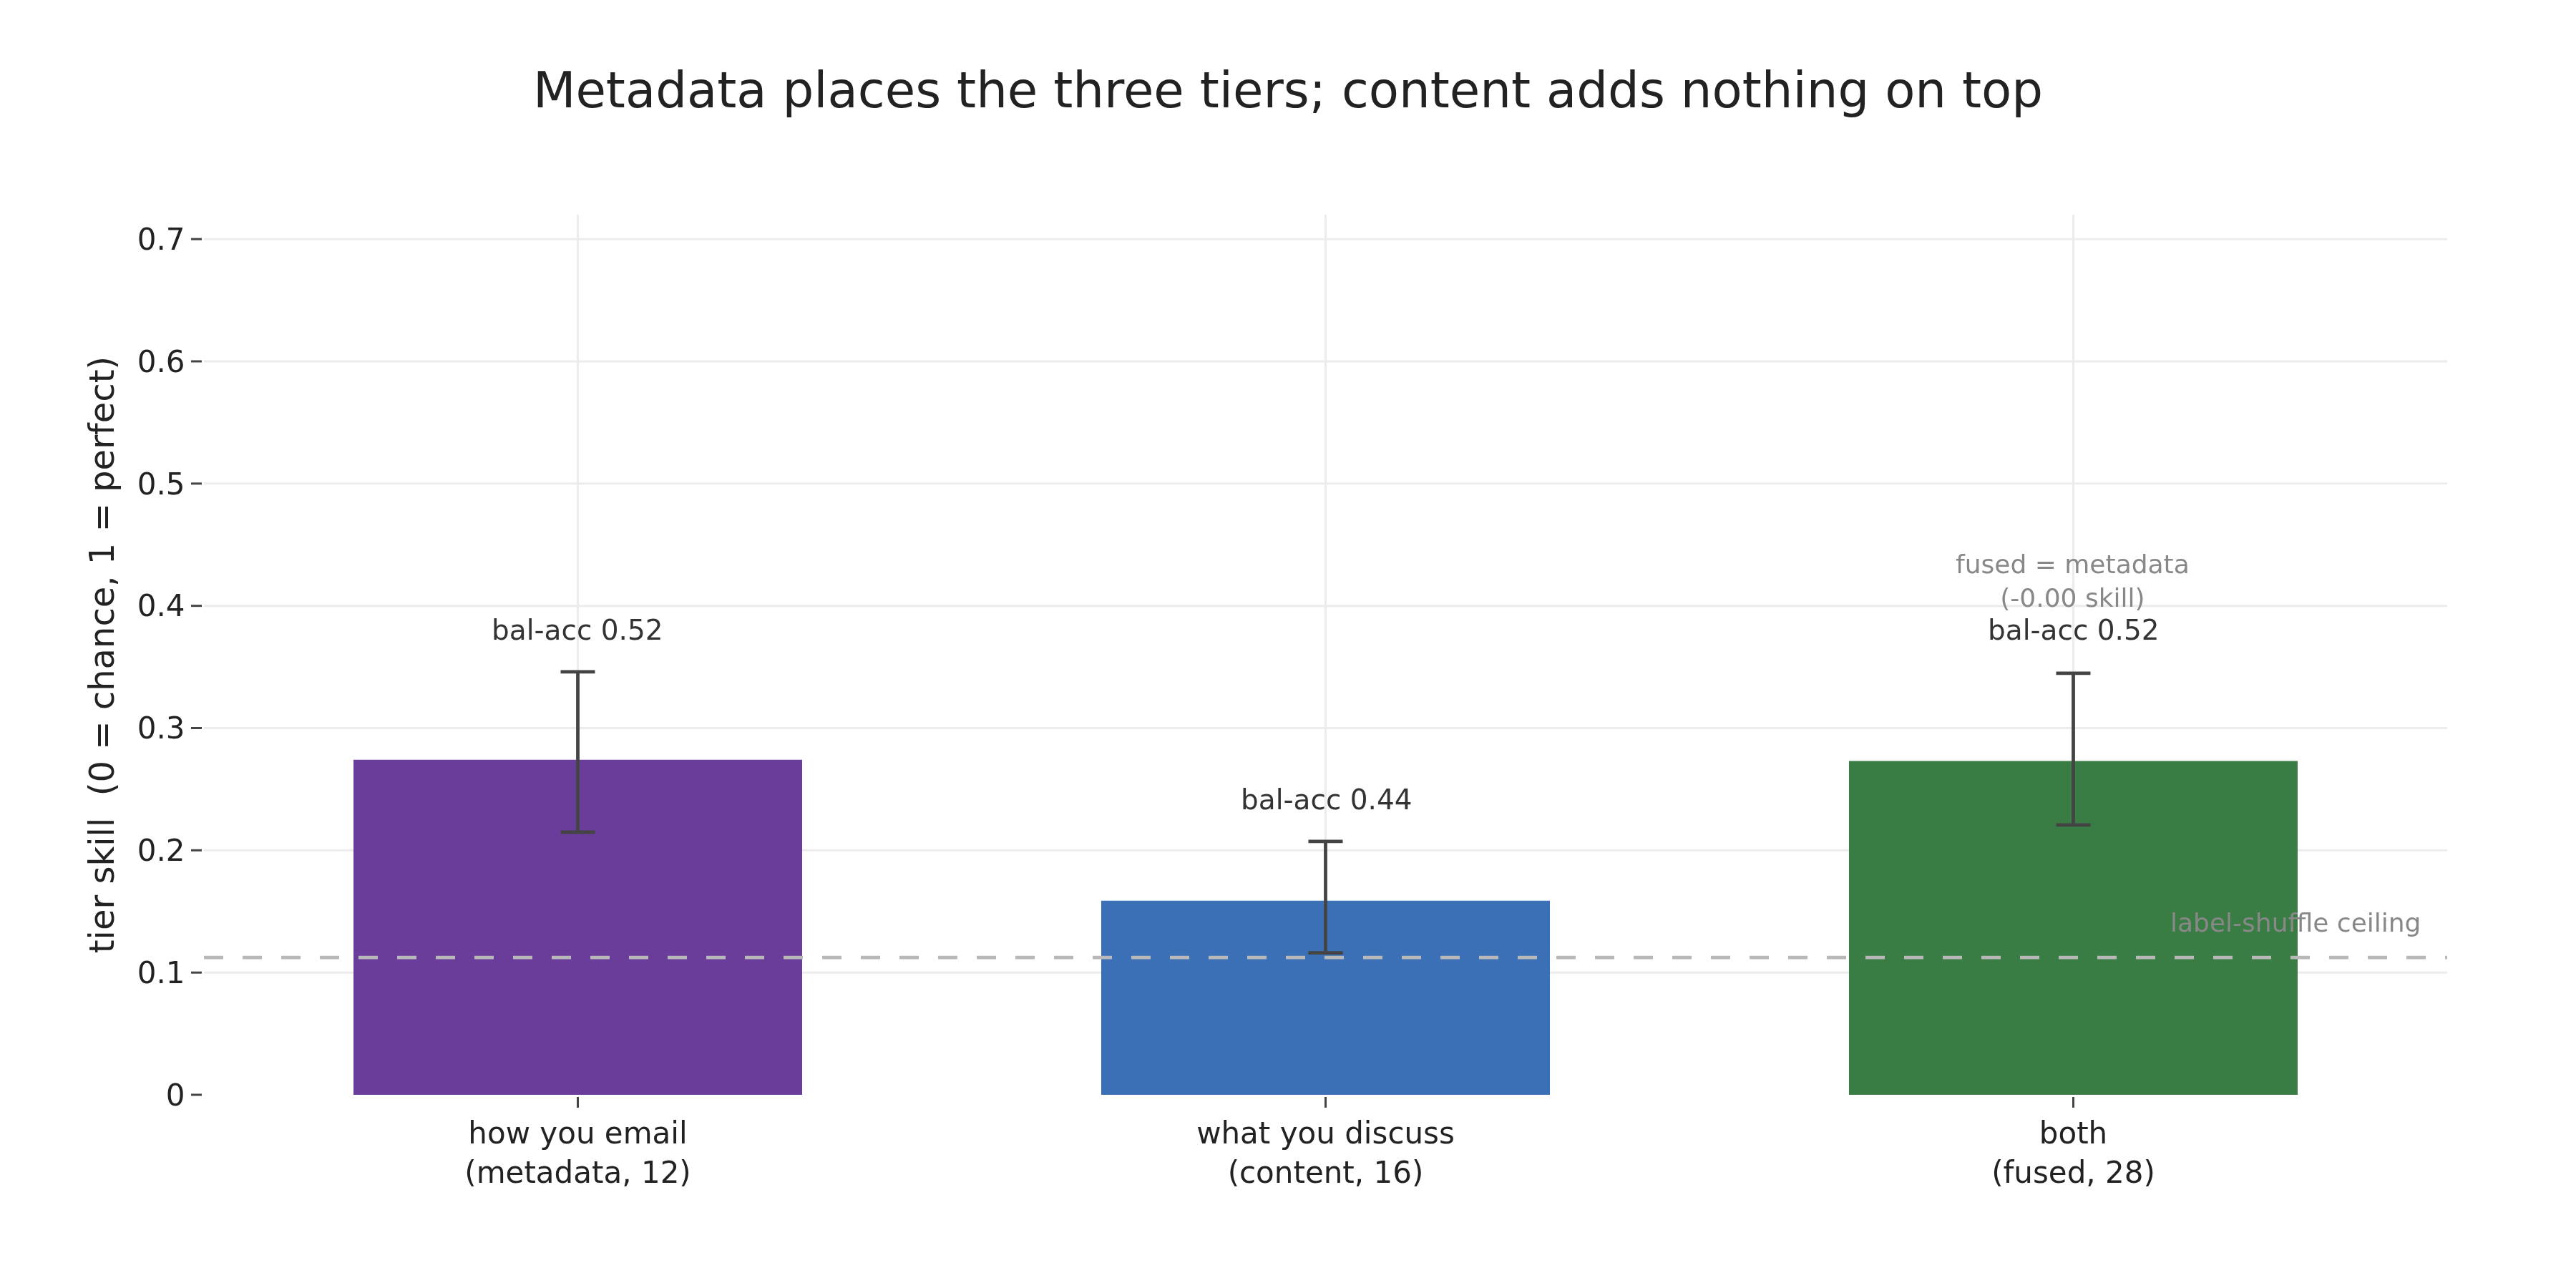

In [3]:
# ===== Experiment 1: collapse the 7 rungs to 3 tiers =====
TIER_X = {1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 7: 2}   # workers / management / executives (MD..CEO)
TIER_Y = {1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 2}   # alt: MD read as management
def tiers(m): return np.array([m[int(r)] for r in y_rank])
yX, yY = tiers(TIER_X), tiers(TIER_Y)
TIER_NAMES = ["workers", "management", "executives"]
print("grouping X sizes", np.bincount(yX), "| grouping Y sizes", np.bincount(yY))

def oof_tier(X, y, rs):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(10, shuffle=True, random_state=rs))
    return balanced_accuracy_score(y, p), f1_score(y, p, average="macro")

R = 40
CHANCE = 1 / 3
def skill(ba): return (np.asarray(ba) - CHANCE) / (1 - CHANCE)
res = {}
for k, X in blocks.items():
    arr = np.array([oof_tier(X, yX, r) for r in range(R)])
    res[k] = dict(ba=arr[:, 0], f1=arr[:, 1])
for k in order3:
    print(f"{k:9s} bal-acc {res[k]['ba'].mean():.3f}  macroF1 {res[k]['f1'].mean():.3f}  "
          f"tier-skill {skill(res[k]['ba']).mean():.3f}")
baY = np.array([oof_tier(Xf, yY, r)[0] for r in range(R)])
print(f"grouping Y fused bal-acc {baY.mean():.3f}  (X fused {res['fused']['ba'].mean():.3f})")

# permutation null on the fused model: shuffle tier labels
rng = np.random.default_rng(0)
NP = 200
null = np.array([oof_tier(Xf, rng.permutation(yX), 0)[0] for _ in range(NP)])
null95 = float(np.percentile(null, 95))
print(f"label-shuffle null bal-acc: mean {null.mean():.3f}  95th {null95:.3f}")

# fused-minus-metadata increment, fixed fold
dba = res["fused"]["ba"] - res["metadata"]["ba"]
print(f"fused - metadata bal-acc: {dba.mean():+.3f} [{np.percentile(dba,2.5):+.3f},{np.percentile(dba,97.5):+.3f}]")

# ---- g1: tier skill of the three blocks ----
def stat(arr):
    m = arr.mean(); return m, np.percentile(arr, 97.5) - m, m - np.percentile(arr, 2.5)
fig = go.Figure()
ms = [stat(skill(res[k]["ba"])) for k in order3]
fig.add_trace(go.Bar(x=[LBL[k] for k in order3], y=[m[0] for m in ms],
    marker_color=[COL3[k] for k in order3], width=0.6,
    error_y=dict(type="data", symmetric=False, array=[m[1] for m in ms], arrayminus=[m[2] for m in ms],
                 color="#444", thickness=1.6, width=8), showlegend=False))
for k, m in zip(order3, ms):
    fig.add_annotation(x=LBL[k], y=m[0] + m[1] + 0.035,
        text=f"bal-acc {res[k]['ba'].mean():.2f}", showarrow=False, font=dict(size=13, color="#333"))
fig.add_hline(y=skill(null95), line=dict(color=GREY, dash="dash", width=1.6))
fig.add_annotation(xref="paper", x=0.99, xanchor="right", y=skill(null95) + 0.028,
    text="label-shuffle ceiling", showarrow=False, font=dict(size=12, color="#888"))
fig.add_annotation(x=LBL["fused"], y=stat(skill(res["fused"]["ba"]))[0] + stat(skill(res["fused"]["ba"]))[1] + 0.075,
    text=f"fused = metadata<br>({2*dba.mean():+.02f} skill)", showarrow=False, font=dict(size=12, color="#888"))
fig.update_yaxes(title_text="tier skill  (0 = chance, 1 = perfect)", range=[0, 0.72])
fig.update_layout(title="Metadata places the three tiers; content adds nothing on top",
    bargap=0.34)
save_fig(fig, "g1_tier_skill.png", w=1200, h=600, margin=dict(l=95, r=60, t=100, b=90))

Metadata places the tier at a balanced accuracy near 0.52, well clear of the label-shuffle ceiling. Content on its own is weaker, and fusing it onto the metadata changes nothing: the two bars sit at the same height. This is the saturation pred-3 saw on the fine ladder. The behavioural window already holds the rank signal, and what a person discusses helps the executive-or-not call but not the job of sorting people among the three tiers.

## Where the tiers blur

The confusion of the fused model, read as row shares, shows which tiers the model tells apart and which it runs together.

confusion (rows true, cols pred):
 [[30 18  8]
 [15 14 10]
 [ 7  9 24]] 
recall [0.54 0.36 0.6 ]
exact 50%  within one tier 89%  off by two 11%  Spearman 0.40


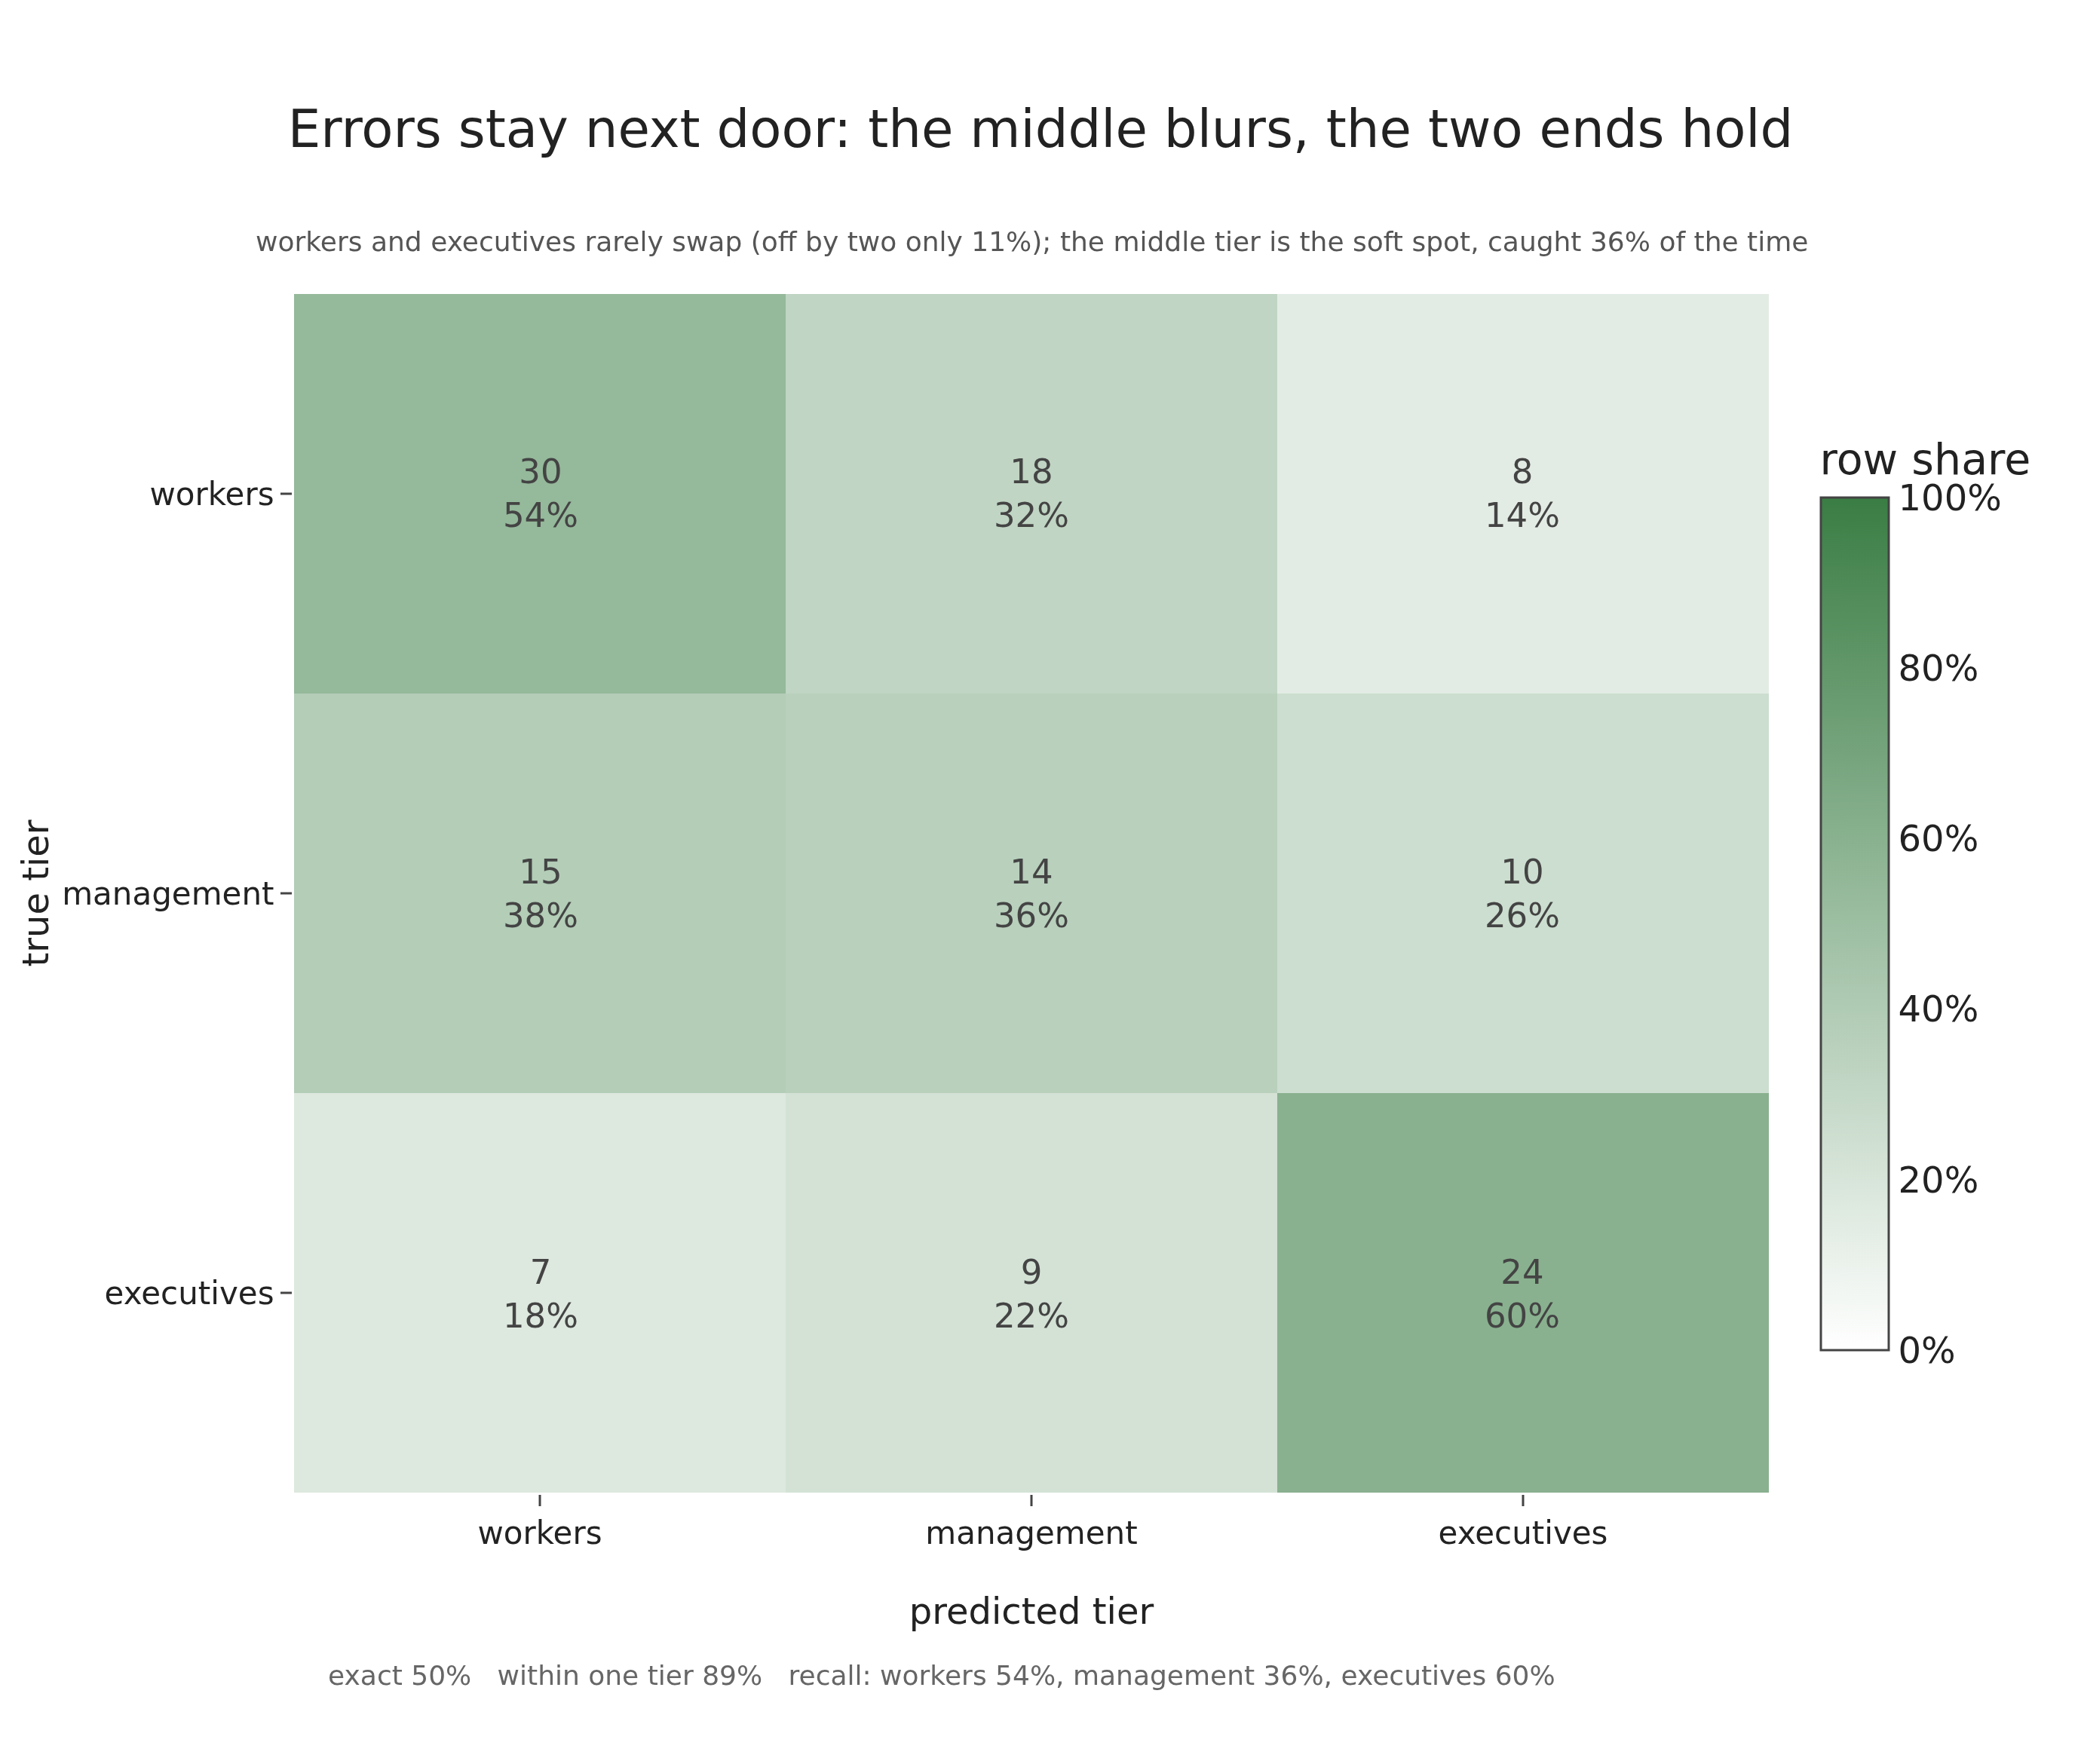

saved g1_tier_skill.png, g2_tier_confusion.png


In [4]:
# ---- g2: 3x3 confusion of the fused model, vs the 7-rung executive recall ----
fold0 = StratifiedKFold(10, shuffle=True, random_state=0)
predX = cross_val_predict(make_pipeline(StandardScaler(),
    LogisticRegression(max_iter=5000, class_weight="balanced")), Xf, yX, cv=fold0)
C = confusion_matrix(yX, predX)
rec = C.diagonal() / C.sum(1)
print("confusion (rows true, cols pred):\n", C, "\nrecall", np.round(rec, 2))

# ordinal error structure: adjacent tiers versus the worker/executive swap
diff = np.abs(yX - predX)
exact = float(np.mean(diff == 0)); within1 = float(np.mean(diff <= 1)); off2 = float(np.mean(diff >= 2))
rho_tier = spearmanr(yX, predX).statistic
print(f"exact {exact:.0%}  within one tier {within1:.0%}  off by two {off2:.0%}  Spearman {rho_tier:.2f}")

Crow = C / C.sum(1, keepdims=True)
txt = [[f"{C[i,j]}<br>{Crow[i,j]:.0%}" for j in range(3)] for i in range(3)]
fig = go.Figure(go.Heatmap(z=Crow, x=TIER_NAMES, y=TIER_NAMES, text=txt, texttemplate="%{text}",
    textfont=dict(size=15), colorscale=[[0, "white"], [1, GREEN]], zmin=0, zmax=1,
    showscale=True, colorbar=dict(title="row share", tickformat=".0%", len=0.8)))
fig.update_xaxes(title_text="predicted tier", side="bottom")
fig.update_yaxes(title_text="true tier", autorange="reversed")
fig.add_annotation(xref="paper", yref="paper", x=0.5, y=1.06, xanchor="center", showarrow=False,
    text=f"workers and executives rarely swap (off by two only {off2:.0%}); "
         f"the middle tier is the soft spot, caught {rec[1]:.0%} of the time", font=dict(size=12, color="#555"))
fig.add_annotation(xref="paper", yref="paper", x=0.02, y=-0.17, xanchor="left", showarrow=False,
    text=f"exact {exact:.0%}   within one tier {within1:.0%}   recall: "
         f"workers {rec[0]:.0%}, management {rec[1]:.0%}, executives {rec[2]:.0%}",
    font=dict(size=12, color="#666"))
fig.update_layout(title="Errors stay next door: the middle blurs, the two ends hold")
save_fig(fig, "g2_tier_confusion.png", w=920, h=780, margin=dict(l=130, r=80, t=130, b=120))

print("saved g1_tier_skill.png, g2_tier_confusion.png")

## What this adds

Collapsing seven rungs to three gives a cleaner target than the full ladder. The model places half the people in exactly the right tier, lands within one tier of the truth for nine in ten, and rarely mistakes a worker for an executive. The middle management tier is the soft spot, absorbed by its neighbours on both sides. What the collapse does not do is unlock new signal: the tier is a metadata call, fusion is flat, and the gain over the seven-rung model is interpretability, not accuracy.